In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import glob
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.cm as cm
import matplotlib.ticker as ticker

Welcome to JupyROOT 6.26/04


In [2]:
cut1 = "Pip_p>0.4 & skimhad==1 & abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8 & etapip_Eta_daughterAngle_0_1<1.6"

In [3]:
def cal_eff_purity_ownMC(file_name,file_list, tree, base_filter, N_gen):
    
    variables = ['Dp_isSignal','Dp_M','__experiment__', '__run__', '__event__','Pip_p','skimhad','Pip_pionID','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1']
    
    N_rec = 0
    N_rec_true = 0

    # Initialize an empty dataframe to store concatenated results
    concatenated_df = pd.DataFrame()

    for file in file_list:
        recon_df = get_pd(file, tree, base_filter, variables)
        N_rec += len(recon_df)
        extracted_df = recon_df[["__experiment__", "__run__", "__event__"]].drop_duplicates()

        # Concatenate the extracted dataframe with the concatenated_df
        concatenated_df = pd.concat([concatenated_df, extracted_df], ignore_index=True)

    multiplicity = len(concatenated_df) / N_rec

    eff = N_rec/N_gen

    # Initialize an empty dataframe to store concatenated results
    concatenated_df2 = pd.DataFrame()

    N_rec2 = 0
    N_rec_true2 = 0
    
    for file in file_list:
        recon_df2 = get_pd(file, tree, base_filter, variables)
        N_rec2 += len(recon_df2)
        extracted_df2 = recon_df2.query('Dp_isSignal==1')
        N_rec_true2 += len(extracted_df2)

        # Concatenate the extracted dataframe with the concatenated_df
        concatenated_df2 = pd.concat([concatenated_df2, extracted_df2], ignore_index=True)
    
    purity = N_rec_true2/N_rec2
    
    print(f"eff={eff:.5f}, purity={purity:.5f}, multiplicity={multiplicity:.5f}")
    
    return (eff, purity, multiplicity)

In [4]:
def cal_eff_purity_ownMC_mcmatched_eff(file_name,file_list, tree, base_filter, N_gen):
    
    variables = ['Dp_isSignal','Dp_M','__experiment__', '__run__', '__event__','Pip_p','skimhad','Pip_pionID','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1']
    if tree=='etapip_gg' or tree=='etapip_gg_K':
        variables += ['dM_pi0_mask_nonan','dM_pi0_mask_2_nonan']
    
    N_rec = 0
    N_rec_true = 0

    # Initialize an empty dataframe to store concatenated results
    concatenated_df = pd.DataFrame()

    for file in file_list:
        recon_df = get_pd(file, tree, base_filter + " & Dp_isSignal==1", variables)
        N_rec += len(recon_df)
        extracted_df = recon_df[["__experiment__", "__run__", "__event__"]].drop_duplicates()

        # Concatenate the extracted dataframe with the concatenated_df
        concatenated_df = pd.concat([concatenated_df, extracted_df], ignore_index=True)

    multiplicity = len(concatenated_df) / N_rec

    eff = N_rec/N_gen

    # Initialize an empty dataframe to store concatenated results
    concatenated_df2 = pd.DataFrame()

    N_rec2 = 0
    N_rec_true2 = 0
    
    for file in file_list:
        recon_df2 = get_pd(file, tree, base_filter, variables)
        N_rec2 += len(recon_df2)
        extracted_df2 = recon_df2.query('Dp_isSignal==1')
        N_rec_true2 += len(extracted_df2)

        # Concatenate the extracted dataframe with the concatenated_df
        concatenated_df2 = pd.concat([concatenated_df2, extracted_df2], ignore_index=True)
    
    purity = N_rec_true2/N_rec2
    
    print(f"eff={eff:.5f}, purity={purity:.5f}, multiplicity={multiplicity:.5f}")
    
    return (eff, purity, multiplicity)

In [5]:
def cal_eff_purity_ownMC_mcmatched_eff_Ds(file_name, file_list, tree, base_filter, N_gen):
    variables = ['Dp_isSignal','Dp_M','__experiment__', '__run__', '__event__','ds_weight', 'Pip_p','skimhad','Pip_pionID','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1']
    
    if tree=='etapip_gg' or tree=='etapip_gg_K':
        variables += ['dM_pi0_mask_nonan','dM_pi0_mask_2_nonan', 'etapip_Eta_isSignal', 'Pip_genMotherID',\
                      'etapip_Eta_genMotherID', 'Pip_genMotherPDG', 'Pip_mcPDG']
    if tree=='etapip_gg_K':
        isSignal_cut = '(etapip_Eta_isSignal == 1 & Pip_genMotherID == etapip_Eta_genMotherID & ((Pip_genMotherPDG == 431 & Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 & Pip_mcPDG == -321)))'
    if tree=='etapip_gg':
        isSignal_cut = '(etapip_Eta_isSignal == 1 & Pip_genMotherID == etapip_Eta_genMotherID & ((Pip_genMotherPDG == 431 & Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 & Pip_mcPDG == -211)))'    
    
    # --- Loop 1: Efficiency & Multiplicity ---
    N_rec_weighted = 0
    
    # Initialize an empty dataframe to store concatenated results
    concatenated_df = pd.DataFrame()

    for file in file_list:
        # Load dataframe with Signal Cut applied
        recon_df = get_pd(file, tree, base_filter + ' & ' + isSignal_cut, variables)
        
        if not recon_df.empty:
            # Sum weights instead of counting rows
            N_rec_weighted += recon_df['ds_weight'].sum()
            
            # For multiplicity: keep event identifiers AND weight, then drop duplicates
            extracted_df = recon_df[["__experiment__", "__run__", "__event__", "ds_weight"]].drop_duplicates()

            # Concatenate the extracted dataframe
            concatenated_df = pd.concat([concatenated_df, extracted_df], ignore_index=True)

    # Sum weights of unique events
    n_unique_events_weighted = concatenated_df['ds_weight'].sum() if not concatenated_df.empty else 0

    # Multiplicity (Weighted Unique Events / Weighted Candidates)
    multiplicity = (n_unique_events_weighted / N_rec_weighted) if N_rec_weighted > 0 else 0

    # Efficiency (Weighted Rec / N_gen)
    # Note: Ideally, N_gen should also be the sum of weights of generated events.
    eff = (N_rec_weighted / N_gen) if N_gen > 0 else 0

    # --- Loop 2: Purity ---
    concatenated_df2 = pd.DataFrame() # Kept for consistency, though unused in calc

    N_rec2_weighted = 0      # Denominator (All candidates)
    N_rec_true2_weighted = 0 # Numerator (Signal candidates)
    
    for file in file_list:
        # Load dataframe WITHOUT Signal Cut
        recon_df2 = get_pd(file, tree, base_filter, variables)
        
        if not recon_df2.empty:
            # Total Reconstructed (Weighted)
            N_rec2_weighted += recon_df2['ds_weight'].sum()
            
            # Apply Signal Cut
            extracted_df2 = recon_df2.query(isSignal_cut)
            
            if not extracted_df2.empty:
                # Signal Matched (Weighted)
                N_rec_true2_weighted += extracted_df2['ds_weight'].sum()

            # Concatenate (optional, based on original code structure)
            concatenated_df2 = pd.concat([concatenated_df2, extracted_df2], ignore_index=True)
    
    purity = (N_rec_true2_weighted / N_rec2_weighted) if N_rec2_weighted > 0 else 0
    
    print(f"eff={eff:.5f}, purity={purity:.5f}, multiplicity={multiplicity:.5f}")
    
    return (eff, purity, multiplicity)

In [6]:
# def cal_eff_purity_ownMC_mcmatched_eff_Ds(file_name,file_list, tree, base_filter, N_gen):
    
#     variables = ['Dp_isSignal','Dp_M','__experiment__', '__run__', '__event__','ds_weight']
#     if tree=='etapip_gg' or tree=='etapip_gg_K':
#         variables += ['dM_pi0_mask_nonan','dM_pi0_mask_2_nonan', 'etapip_Eta_isSignal', 'Pip_genMotherID',\
#                      'etapip_Eta_genMotherID', 'Pip_genMotherPDG', 'Pip_mcPDG']
#     if tree=='etapip_gg_K':
#         isSignal_cut = '(etapip_Eta_isSignal == 1 & Pip_genMotherID == etapip_Eta_genMotherID & ((Pip_genMotherPDG == 431 & Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 & Pip_mcPDG == -321)))'
#     if tree=='etapip_gg':
#         isSignal_cut = '(etapip_Eta_isSignal == 1 & Pip_genMotherID == etapip_Eta_genMotherID & ((Pip_genMotherPDG == 431 & Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 & Pip_mcPDG == -211)))'    
#     N_rec = 0
#     N_rec_true = 0

#     # Initialize an empty dataframe to store concatenated results
#     concatenated_df = pd.DataFrame()

#     for file in file_list:
#         recon_df = get_pd(file, tree, base_filter + ' & ' + isSignal_cut, variables)
#         N_rec += len(recon_df)
#         extracted_df = recon_df[["__experiment__", "__run__", "__event__"]].drop_duplicates()

#         # Concatenate the extracted dataframe with the concatenated_df
#         concatenated_df = pd.concat([concatenated_df, extracted_df], ignore_index=True)

#     multiplicity = len(concatenated_df) / N_rec

#     eff = N_rec/N_gen

#     # Initialize an empty dataframe to store concatenated results
#     concatenated_df2 = pd.DataFrame()

#     N_rec2 = 0
#     N_rec_true2 = 0
    
#     for file in file_list:
#         recon_df2 = get_pd(file, tree, base_filter, variables)
#         N_rec2 += len(recon_df2)
#         extracted_df2 = recon_df2.query(isSignal_cut)
#         N_rec_true2 += len(extracted_df2)

#         # Concatenate the extracted dataframe with the concatenated_df
#         concatenated_df2 = pd.concat([concatenated_df2, extracted_df2], ignore_index=True)
    
#     purity = N_rec_true2/N_rec2
    
#     print(f"eff={eff:.5f}, purity={purity:.5f}, multiplicity={multiplicity:.5f}")
    
#     return (eff, purity, multiplicity)

In [7]:
def calculate_sig_eff_err(eff, N_gen):

    error = math.sqrt(eff * (1 - eff) / N_gen)
    return error

# D+ -> eta pi+

In [8]:
# Numer of files should be 22*2 = 44

In [9]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/251219_loose_v7_wihtoutpi0veto_v2/251219*.root'
base_filter=' Dp_M>1.76 && Dp_M<1.96'
base_filter=' (Dp_M>1.78) & (Dp_M<1.94) & (skimhad==1) & (Pip_p>0.4) & (abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8) & (etapip_Eta_daughterAngle_0_1<1.6)'

tree = 'etapip_gg'
root_files = glob.glob(file)

file_cc = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/251219_loose_v7_wihtoutpi0veto_v2/251219*.root'
root_files += glob.glob(file_cc)

print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff(file,root_files, tree, base_filter, 6e+6)

df = get_pd(file=file, tree=tree,base_filter='Dp_M>0',variables=['Dp_M','Dp_isSignal'])
df_cc = get_pd(file=file_cc, tree=tree,base_filter='Dp_M>0',variables=['Dp_M','Dp_isSignal'])

df_all = pd.concat([df, df_cc], ignore_index=True)
df_all_true = df_all.query('Dp_isSignal==1')

std_dev_Dp_M = df_all_true['Dp_M'].std()
print("Standard deviation of column 'Dp_M':", std_dev_Dp_M)

# x_start = 1.8697 - 2.5*std_dev_Dp_M
# x_end = 1.8697 + 2.5*std_dev_Dp_M

x_start = 1.8697 - 4.2*std_dev_Dp_M
x_end = 1.8697 + 3.8*std_dev_Dp_M

print(x_start)
print(x_end)

44
eff=0.14047, purity=0.89701, multiplicity=0.99991
Standard deviation of column 'Dp_M': 0.022006591332399267
1.777272316403923
1.9533250470631172


Warning in <TClass::Init>: no dictionary for class Belle2::FileMetaData is available


In [10]:
print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff(file,root_files, tree, base_filter + ' & dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011', 6e+6) 

44
eff=0.11700, purity=0.91783, multiplicity=0.99993


In [11]:
1 - (0.15434 - 0.12635)/0.15434

0.8186471426720228

827325


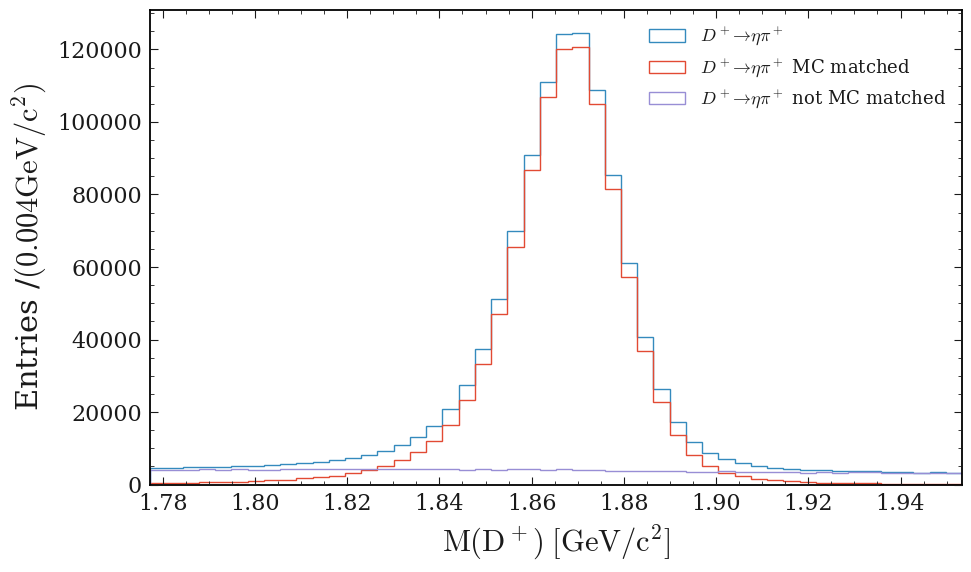

In [12]:
variables = ['Dp_M','Dp_isSignal','Dp_chiProb','Dp_mcErrors']

# df_all = get_pd(file=file, tree=tree,base_filter=base_filter,variables=variables)
df2 = df_all.query('Dp_isSignal==1')
df3 = df_all.query('Dp_isSignal!=1')

fig = plt.figure(figsize=(10, 6))

ax = fig.subplots()
xrange = (x_start,x_end,51)

xm = np.linspace(*xrange)

# df = pd_df_test
# df2 = pd_df_test2

N_df = len(df_all)
N_df2 = len(df2)
N_df3 = len(df3)

plt.hist(df_all["Dp_M"],bins=xm,histtype='step',label=r'$D^+ \to \eta \pi^+$');
plt.hist(df2["Dp_M"],bins=xm,histtype='step',label=r'$D^+ \to \eta \pi^+$ MC matched');
plt.hist(df3["Dp_M"],bins=xm,histtype='step',label=r'$D^+ \to \eta \pi^+$ not MC matched');

plt.legend(loc="upper right",fontsize=13)
# ax.set_title(r'MC15ri 1M' )

n, xe = np.histogram(df["Dp_M"], bins=50, range=(xrange[0],xrange[1]))

plt.xlabel("$\mathrm{M(D^+)} \; [\mathrm{GeV/c^2}]$")
width = xe[1]-xe[0]
plt.ylabel('Entries'+' /' + '$(' + ' '  + "{0:.3f}".format(width).rstrip('0').rstrip('.') + '\mathrm{GeV/c^2})$');

plt.xlim(xrange[0],xrange[1])
plt.tight_layout()
# file1_name="/media/jykim/T7/saved_plots/DRAW/etapip/MC15ri_sig/gg/MC15ri_tight_v1_DpM_BCS_SR.png"
# plt.savefig(file1_name)
print(len(df))

# D+ -> eta K+

In [13]:
# Numer of files should be 22*2 = 44

In [14]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/251219_loose_v7_wihtoutpi0veto_v2/251219*.root'
base_filter=' Dp_M>1.76 && Dp_M<1.96'
base_filter=' (Dp_M>1.78) && (Dp_M<1.94) & (skimhad==1) & (Pip_p>0.4) & (Pip_pionID<0.01) & (abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8) & (etapip_Eta_daughterAngle_0_1<1.6)'

tree = 'etapip_gg_K'
root_files = glob.glob(file)

file_cc = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/251219_loose_v7_wihtoutpi0veto_v2/251219*.root'
root_files += glob.glob(file_cc)

print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff(file,root_files, tree, base_filter, 6e+6)

df = get_pd(file=file, tree=tree,base_filter='Dp_M>0',variables=['Dp_M','Dp_isSignal'])
df_cc = get_pd(file=file_cc, tree=tree,base_filter='Dp_M>0',variables=['Dp_M','Dp_isSignal'])

df_all = pd.concat([df, df_cc], ignore_index=True)
df_all_true = df_all.query('Dp_isSignal==1')

std_dev_Dp_M = df_all_true['Dp_M'].std()
print("Standard deviation of column 'Dp_M':", std_dev_Dp_M)

# x_start = 1.8697 - 2.5*std_dev_Dp_M
# x_end = 1.8697 + 2.5*std_dev_Dp_M

x_start = 1.8697 - 4.2*std_dev_Dp_M
x_end = 1.8697 + 3.8*std_dev_Dp_M

print(x_start)
print(x_end)

44
eff=0.12170, purity=0.92814, multiplicity=0.99996
Standard deviation of column 'Dp_M': 0.016761855191416992
1.7993002081960485
1.9333950497273844


In [15]:
print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff(file,root_files, tree, base_filter + ' & dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011', 6e+6) 

44
eff=0.10038, purity=0.95193, multiplicity=0.99996


In [16]:
1 - (0.13320 - 0.10816)/0.13320

0.812012012012012

# Ds+ -> eta pi+

In [17]:
# Numer of files should be 22*2 = 44

In [18]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg/251219_loose_v7_wihtoutpi0veto_v2/weighted/251219*.root'
base_filter=' (Dp_M>1.88) & (Dp_M<2.04) & (skimhad==1) & (Pip_p>0.4) & (abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8) & (etapip_Eta_daughterAngle_0_1<1.6)'

tree = 'etapip_gg'
root_files = glob.glob(file)

file_cc = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg_cc/251219_loose_v7_wihtoutpi0veto_v2/weighted/251219*.root'
root_files += glob.glob(file_cc)

print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff_Ds(file,root_files, tree, base_filter, 6e+6)


44
eff=0.15250, purity=0.90749, multiplicity=0.99998


Error in <TList::Clear>: A list is accessing an object (0x5615af750230) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615af8d5390) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615b089d450) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615af74d860) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615afe468d0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615afe4a7d0) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615afc17450) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615ada9f870) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x5615aea34c40) already deleted (list name = TList)
Error in <TList::Clear>: A l

In [19]:
print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff_Ds(file,root_files, tree, base_filter + ' & dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011', 6e+6) 

44
eff=0.13247, purity=0.92449, multiplicity=0.99998


In [20]:
1 - (0.16661 - 0.14224)/0.16661

0.853730268291219

# Ds+ -> eta K+

In [21]:
# Numer of files should be 22*2 = 44

In [22]:
file = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg/251219_loose_v7_wihtoutpi0veto_v2/weighted/251219*.root'
base_filter=' (Dp_M>1.86) & (Dp_M<2.06) & (skimhad==1) & (Pip_p>0.4) & (Pip_pionID<0.01) & (abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8) & (etapip_Eta_daughterAngle_0_1<1.6)'

tree = 'etapip_gg_K'
root_files = glob.glob(file)

file_cc = '/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DsptoetaKp_gg_cc/251219_loose_v7_wihtoutpi0veto_v2/weighted/251219*.root'
root_files += glob.glob(file_cc)

print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff_Ds(file,root_files, tree, base_filter, 6e+6)


44
eff=0.13064, purity=0.88568, multiplicity=0.99997


In [23]:
print(len(root_files))
D0eff,D0purity,D0multiplicity = cal_eff_purity_ownMC_mcmatched_eff_Ds(file,root_files, tree, base_filter + ' & dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011', 6e+6) 

44
eff=0.11285, purity=0.90788, multiplicity=0.99997


In [25]:
0.11285/0.13064

0.8638242498469075